Common Modules: {'levelshifter', 'Array', 'Sense_Amp', 'wlDecoderDriver', 'RNG_Block', 'ADC', 'periphery'}
Digital-Only Modules: {'Sense_Amp'}
ps-Only Modules: set()
Pure-Only Modules: set()
Digital RNG keys: ['RNG_Block']
ps SRAM RNG keys: ['RNG_Block']


/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_30568/2498665736.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


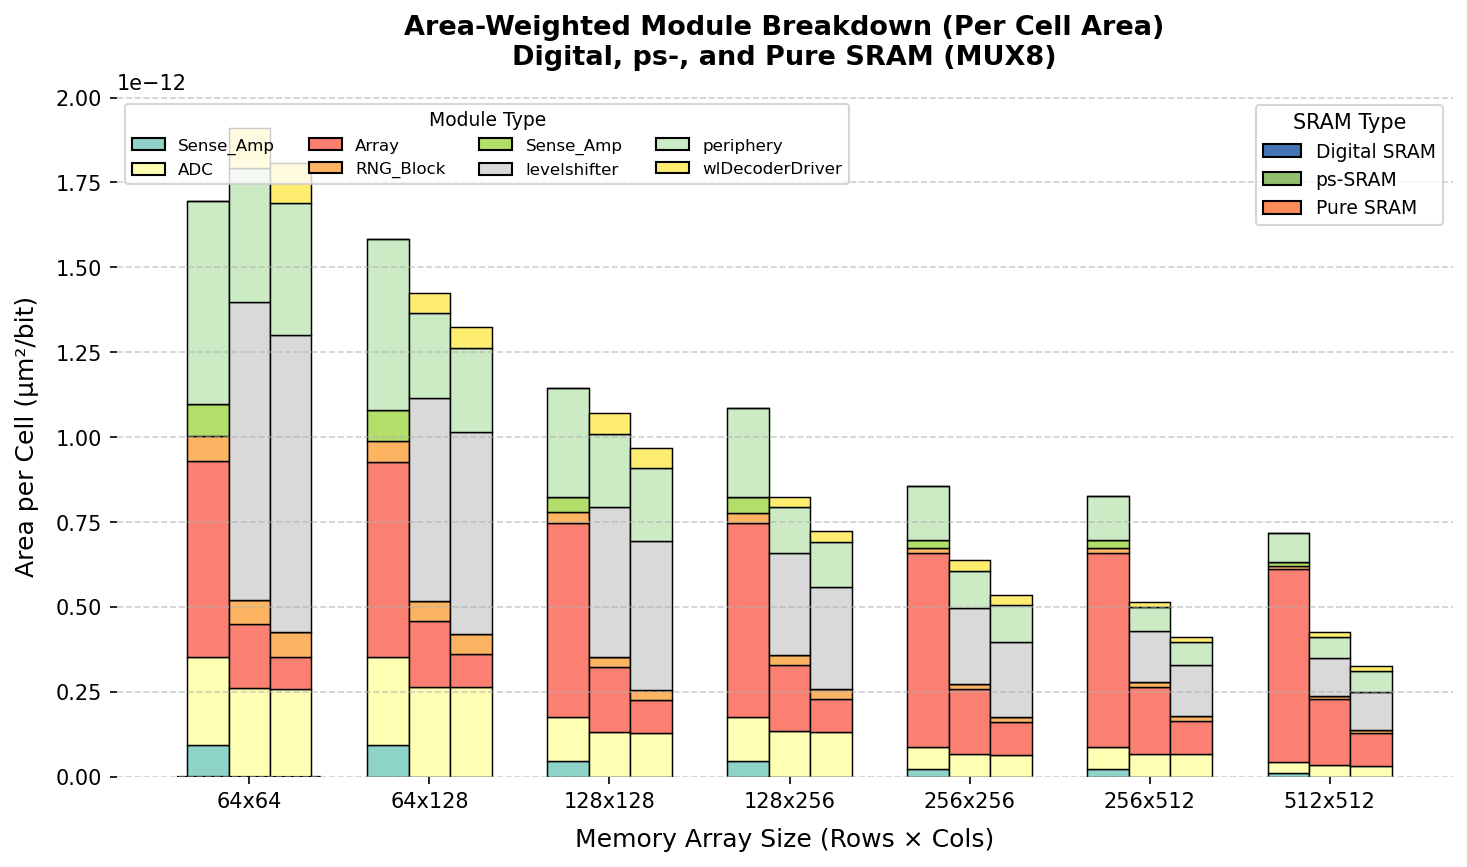

In [39]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num", "MUX_Block","MUX_BLOCK","MUX_Bus",
            "MUX","MUX_Decoder","WL_Decoder","Pre_Charge","Pre_charge",
            "SRAM_Write_Driver","Total Area","Used_area","Used Area",
            "Memory_Density (bits/um^2)","Used_memory_Density (bits/um^2)",
            "Used_Memory_Density (bits/um^2)","Used_memory_density (bits/um^2)"
        ]

        # 提取模块面积
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "Used_area": data["Used Area"]
            # "density": data[key_density_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
digital_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/area"
ps_folder = "./Data/simulation/ps_RRAM/4bitADC/ARNG1/mux8/area"
pure_folder = "./Data/simulation/ps_FeFET/4bitADC/ARNG1/mux8/area"

digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Used_memory_density (bits/um^2)")
ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Used_memory_Density (bits/um^2)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

# ===================== 模块排序：共同模块在下，独有模块在上 =====================
# 模块全集（不考虑是否某 SRAM 为 0）
set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块：只看命名，不看是否某些 size 有 0
common_modules = set_ps | set_dig | set_pure

# 独有模块（几乎不会发生，除非名字真不同）
ps_only = set_ps - (set_dig | set_pure)
dig_only = set_dig - (set_ps | set_pure)
pure_only = set_pure - (set_ps | set_dig)

# common_modules = set_ps & set_dig & set_pure
# ps_only = set_ps - common_modules
# dig_only = set_dig - common_modules
# pure_only = set_pure - common_modules
print("Common Modules:", common_modules)
print("Digital-Only Modules:", dig_only)
print("ps-Only Modules:", ps_only)
print("Pure-Only Modules:", pure_only)
# modules = (
#     sorted(common_modules) +
#     sorted(dig_only) +
#     sorted(ps_only) +
#     sorted(pure_only)
# )

modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

print("Digital RNG keys:", [k for k in digital_break[next(iter(digital_break))].keys() if "RNG" in k.upper()])
print("ps SRAM RNG keys:", [k for k in ps_break[next(iter(ps_break))].keys() if "RNG" in k.upper()])
# ===================== Cell Area 计算 =====================
digital_area_per_cell = [
    d["Used_area"] / d["area"] for d in digital_data
]
ps_area_per_cell = [
    d["Used_area"] / d["area"] for d in ps_data
]
pure_area_per_cell = [
    d["Used_area"] / d["area"] for d in pure_data
]

memory_sizes = [d["label"] for d in ps_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D",
    "pure": "#FC8D59"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

UNIFORM_ALPHA = 1.0

# ===================== 绘图函数 =====================
def plot_stacked(breakdowns, values, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * values[j]
            for j, size in enumerate(memory_sizes)
        ]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=module_colors[i],
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

plot_stacked(digital_break, digital_area_per_cell, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_area_per_cell, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_area_per_cell, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM'),
    Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Area per Cell (μm²/bit)", fontsize=12, labelpad=8)

plt.title(
    "Area-Weighted Module Breakdown (Per Cell Area)\nDigital, ps-, and Pure SRAM (MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_area_three_types_color_blend_nv_device.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_30568/4007558243.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


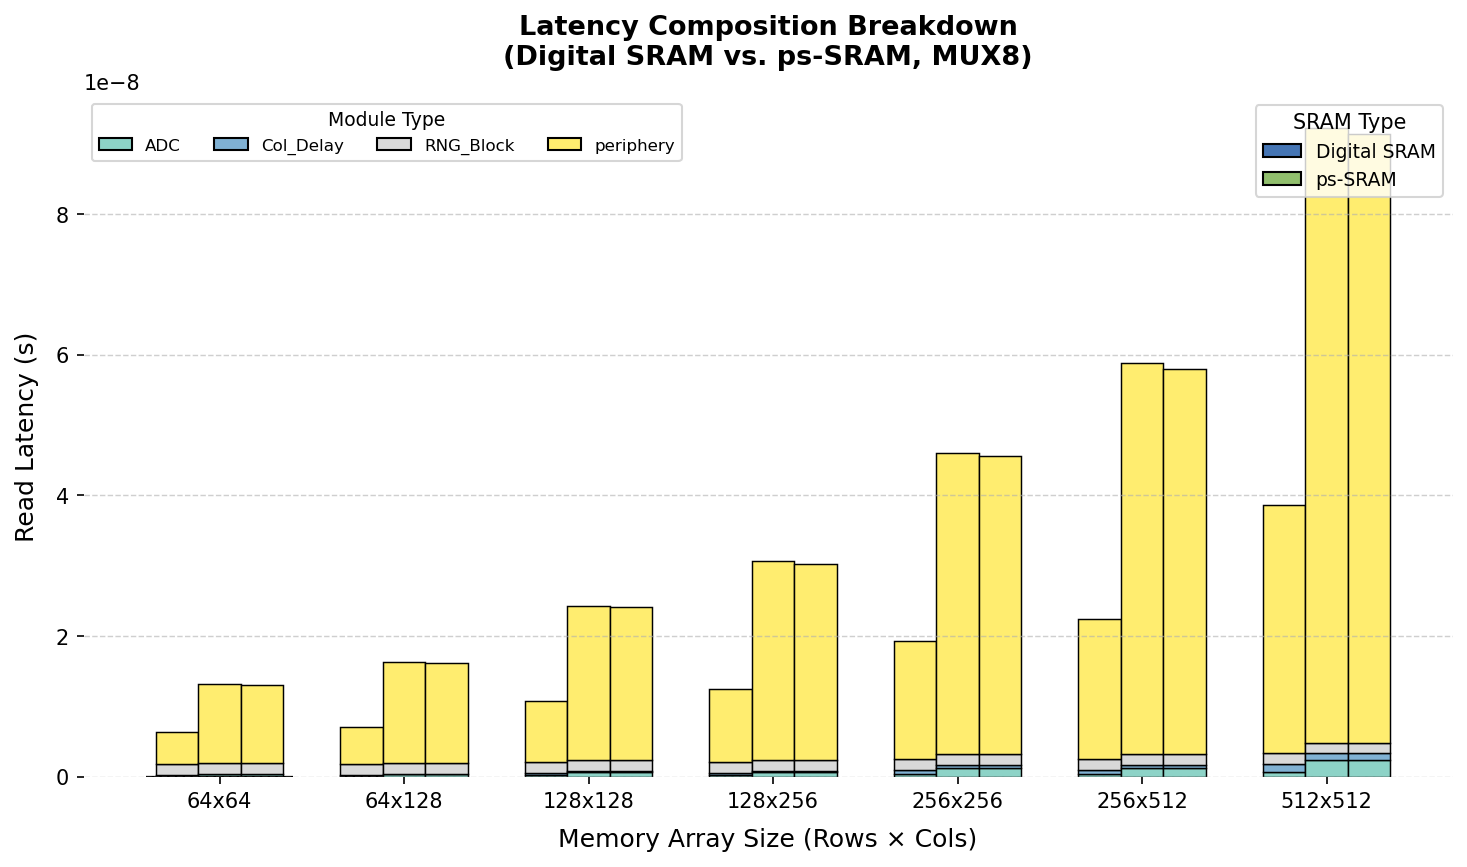

In [32]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_latency_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder", "MUX_Block", "MUX_BLOCK",
            "WL_Decoder", "Pre_Charge", "Pre_charge", "Precharger",
            "SRAM_Write_Driver","wlDecoderDriver",
            "Total Read Latency (s)", "Total Read Latency (cycles)",
            "Throughput (bits/s)"
        ]

        # 提取模块面积
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比

        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "latency": data[key_latency_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
digital_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/latency"
ps_folder = "./Data/simulation/ps_RRAM/4bitADC/ARNG1/mux8/latency"
pure_folder = "./Data/simulation/ps_FeFET/4bitADC/ARNG1/mux8/latency"


ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Latency (s)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Latency (s)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Total Read Latency (s)")

# ===================== 模块排序（共同模块在下，独有模块在上） =====================
set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块：只看命名，不看是否某些 size 有 0
common_modules = set_ps | set_dig | set_pure

# 独有模块（几乎不会发生，除非名字真不同）
ps_only = set_ps - (set_dig | set_pure)
dig_only = set_dig - (set_ps | set_pure)
pure_only = set_pure - (set_ps | set_dig)

# modules = (
#     sorted(common_modules) +
#     sorted(dig_only) +
#     sorted(ps_only) +
#     sorted(pure_only)
# )

modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)

# ===================== 数据提取 =====================
memory_sizes = [d["label"] for d in ps_data]
ps_latency = [d["latency"] for d in ps_data]
digital_latency = [d["latency"] for d in digital_data]
pure_latency = [d["latency"] for d in pure_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D",
    "pure": "#FC8D59"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23
UNIFORM_ALPHA = 1.0

def plot_stacked(breakdowns, latency, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * latency[j]
            for j, size in enumerate(memory_sizes)
        ]
        color = module_colors[i]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=UNIFORM_ALPHA)


# ===================== 主图 =====================
plot_stacked(digital_break, digital_latency, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_latency, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_latency, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i], alpha=UNIFORM_ALPHA)
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
]

# SRAM 类型图例
first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

# 模块图例
plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Read Latency (s)", fontsize=12, labelpad=8)

plt.title(
    "Latency Composition Breakdown\n(Digital SRAM vs. ps-SRAM, MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# # ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_latency_two_types_nv_device.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_30568/2130401927.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


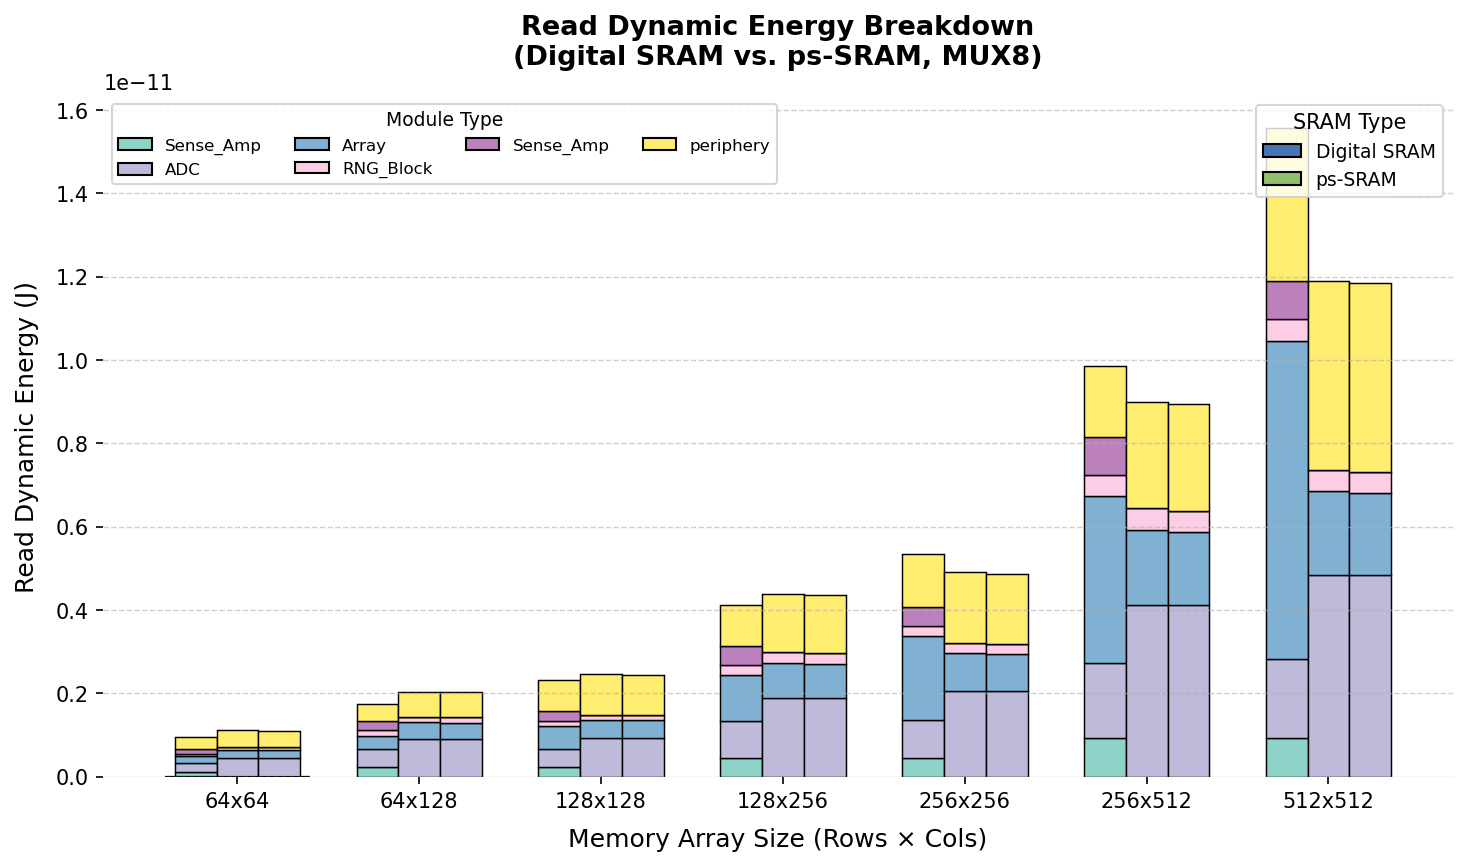

In [31]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_energy_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()

    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)

        label = f"{data['num_rows']}x{data['num_cols']}"

        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "num_col_muxed",
            "adc_precision", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder", "MUX_Block", "MUX_BLOCK",
            "WL_Decoder", "Pre_Charge", "Pre_charge", "Precharger",
            "SRAM_Write_Driver","wlDecoderDriver",
            "Total Read Dynamic Energy (J)", "Leakage Power (W)",
            "Total Read Latency (s)", "Total Read Latency (cycles)",
            "Throughput (bits/s)"
        ]

        # 提取模块动态能量
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_energy = sum(breakdown.values())
        breakdown = {k: v / total_energy for k, v in breakdown.items()}  # 模块占比

        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "energy": data[key_energy_name]
        })

    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
digital_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/energy"
ps_folder = "./Data/simulation/ps_RRAM/4bitADC/ARNG1/mux8/energy"
pure_folder = "./Data/simulation/ps_FeFET/4bitADC/ARNG1/mux8/energy"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Dynamic Energy (J)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Dynamic Energy (J)")
pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Total Read Dynamic Energy (J)")

# ===================== 模块排序：共同在下，独有在上 =====================
set_ps = set(ps_mod)
set_dig = set(dig_mod)
set_pure = set(pure_mod)

# 共同模块：只看命名，不看是否某些 size 有 0
common_modules = set_ps | set_dig | set_pure

# 独有模块（几乎不会发生，除非名字真不同）
ps_only = set_ps - (set_dig | set_pure)
dig_only = set_dig - (set_ps | set_pure)
pure_only = set_pure - (set_ps | set_dig)

modules = (
    sorted(common_modules) +
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only)
)

modules = (
    sorted(dig_only) +
    sorted(ps_only) +
    sorted(pure_only) +
    sorted(common_modules)
)
# ===================== 提取数据 =====================
memory_sizes = [d["label"] for d in ps_data]
ps_energy = [d["energy"] for d in ps_data]
digital_energy = [d["energy"] for d in digital_data]
pure_energy = [d["energy"] for d in pure_data]

# ===================== 配色方案 =====================
base_colors = {
    "digital": "#4575B4",
    "ps": "#91BF6D",
    "pure": "#FC8D59"
}

cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23
UNIFORM_ALPHA = 1.0

def plot_stacked(breakdowns, energies, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))

    for i, module in enumerate(modules):
        vals = [
            breakdowns.get(size, {}).get(module, 0) * energies[j]
            for j, size in enumerate(memory_sizes)
        ]

        plt.bar(
            x + offset,
            vals,
            bar_width,
            bottom=bottom,
            color=module_colors[i],
            edgecolor='black',
            linewidth=0.7,
            alpha=UNIFORM_ALPHA
        )

        bottom += np.array(vals)

    # 主标签
    plt.bar(
        0, 0,
        color=base_tint,
        edgecolor='black',
        label=label,
        alpha=UNIFORM_ALPHA
    )


# ===================== 主图 =====================
plot_stacked(digital_break, digital_energy, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_energy, 0, "ps-SRAM", base_colors["ps"])
plot_stacked(pure_break, pure_energy, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
]

first_legend = plt.legend(
    handles=type_handles,
    fontsize=9,
    loc='upper right',
    title="SRAM Type",
    title_fontsize=10,
    frameon=True
)
plt.gca().add_artist(first_legend)

plt.legend(
    handles=module_handles,
    fontsize=8,
    ncol=4,
    loc='upper left',
    title="Module Type",
    title_fontsize=9,
    frameon=True
)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Read Dynamic Energy (J)", fontsize=12, labelpad=8)

plt.title(
    "Read Dynamic Energy Breakdown\n(Digital SRAM vs. ps-SRAM, MUX8)",
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_energy_two_types_nv_device.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/751039518.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


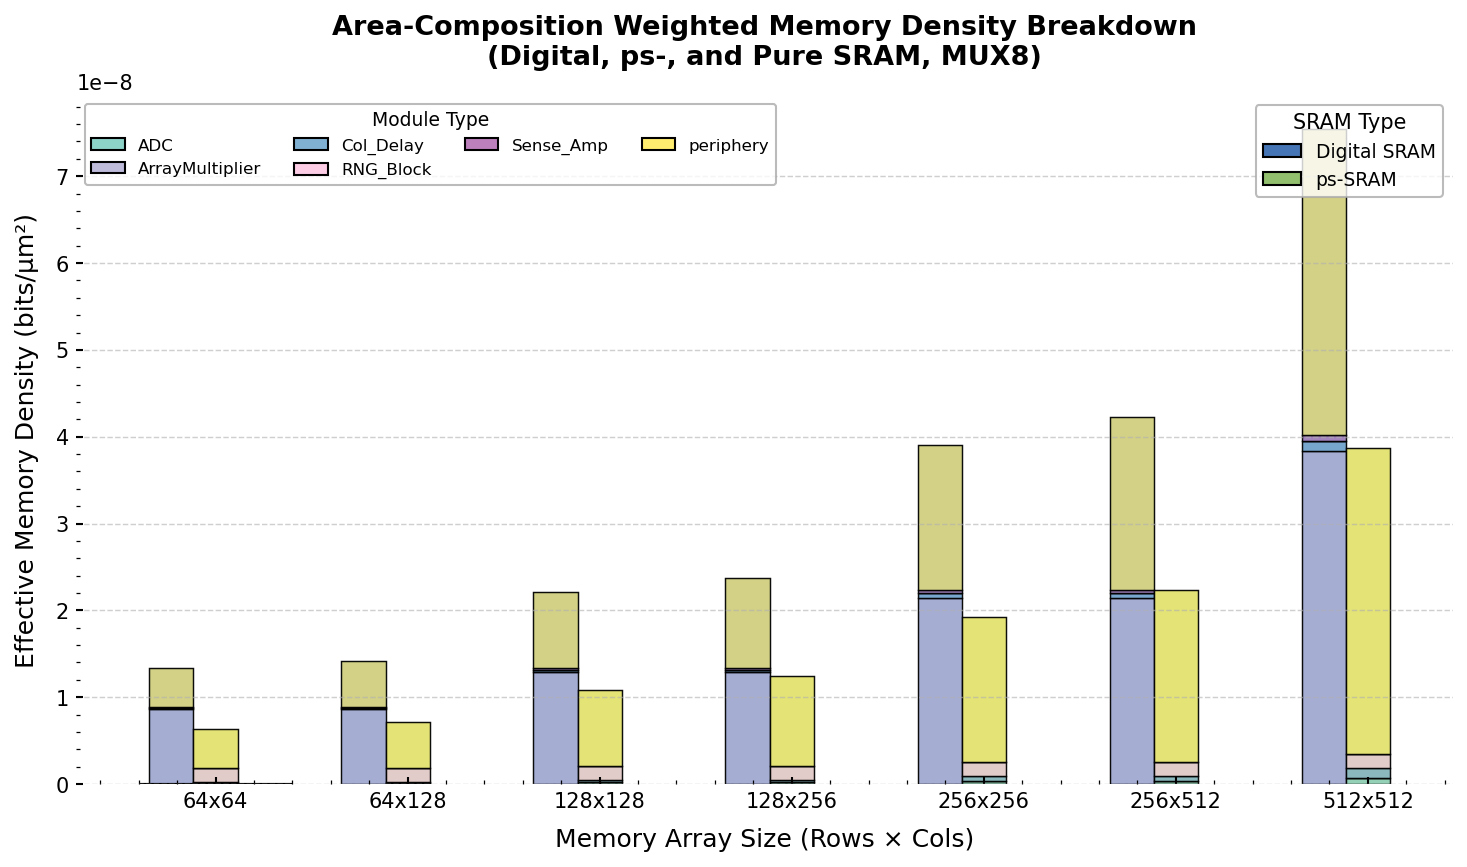

In [34]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_col_muxed","MUX_Bus","MUX","MUX_Decoder","MUX_Block","WL_Decoder",
            "Pre_Charge","Pre_charge","SRAM_Write_Driver","num_muxed_cols","adc_precision","MUX_BLOCK","Precharger",
            "Total Read Latency (s)","Throughput (bits/s)", "Total Read Latency (cycles)",
            "num_rows", "num_cols", "clt_num",
            "MUX_Bus", "MUX", "MUX_Decoder",
            "Throughput (bits/s)", "Total Read Latency (s)", "Total Read Latency (cycles)"
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/latency"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/latency"
# pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Latency (s)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Latency (s)")
# pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

modules = sorted(set(ps_mod + dig_mod))

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
# pure_density = [d["density"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [breakdowns.get(size, {}).get(module, 0) * densities[j]
                for j, size in enumerate(memory_sizes)]
        color = blend_colors(base_tint, module_colors[i], alpha=0.25)
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.95
        )
        bottom += np.array(vals)
    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=0.95)


# 绘制三种 SRAM
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
# plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
    # Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Type", title_fontsize=9, frameon=True)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_latency_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

/var/folders/fz/29pbk9_x3cx_bbdhfpt2f2zc0000gn/T/ipykernel_10088/3340250671.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set3', len(modules))


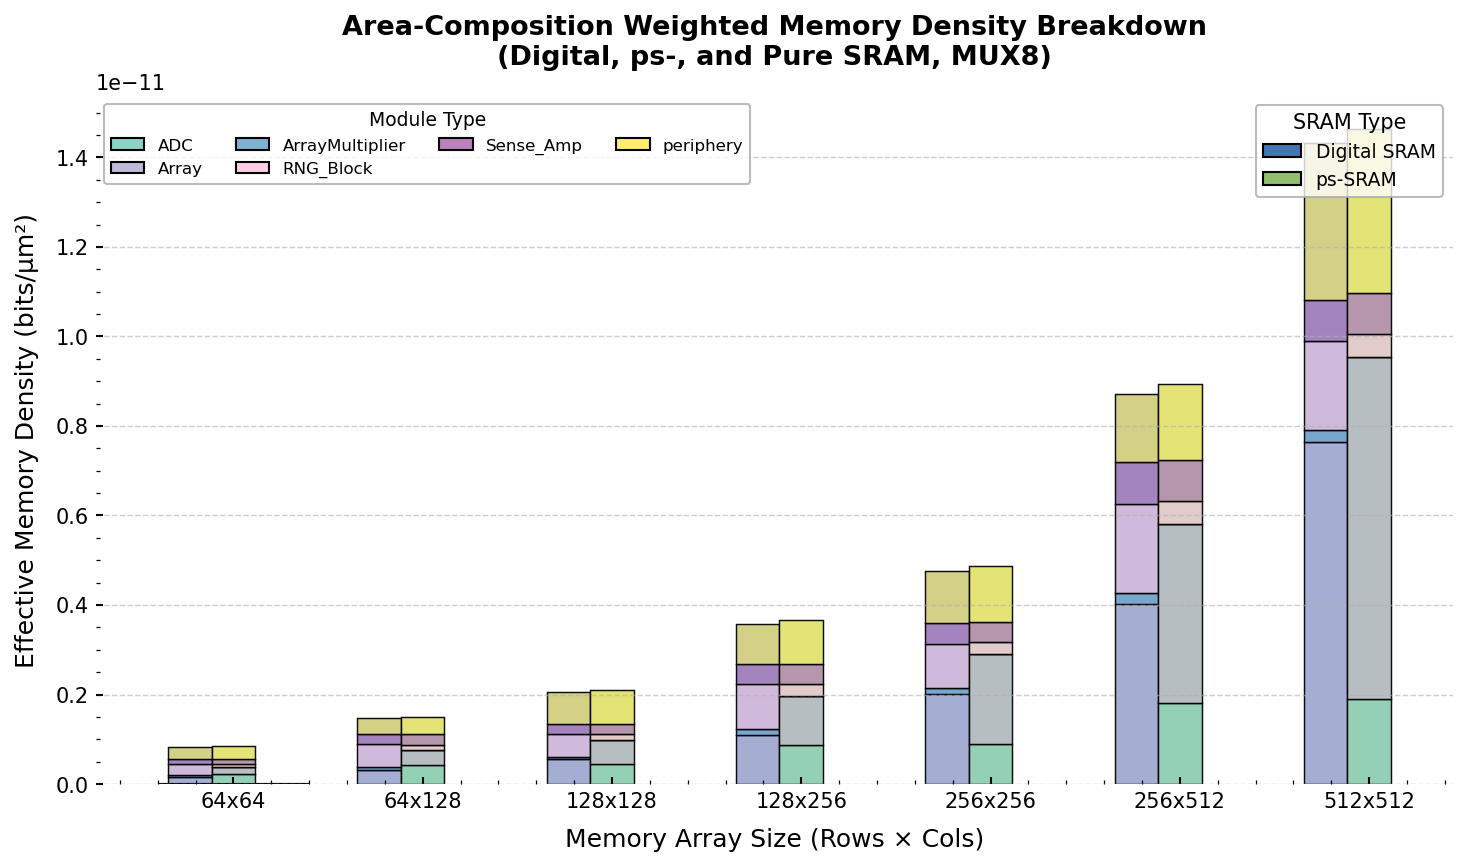

In [35]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.colors import to_rgb

# ===================== 基础设置 =====================
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# ===================== 通用函数 =====================
def load_breakdown(folder, key_density_name):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    data_list, breakdowns, modules = [], {}, set()
    for file in files:
        with open(os.path.join(folder, file), "r") as f:
            data = json.load(f)
        label = f"{data['num_rows']}x{data['num_cols']}"
        exclude_keys = [
            "num_rows", "num_cols", "num_muxed_cols", "adc_precision","MUX_Bus","MUX","MUX_Decoder","MUX_Block",
            "wl_decoder_leakage", "precharger_leakage", "sram_write_driver_leakage",
            "Total Read Dynamic Energy (J)", "Leakage Power (W)","num_rows", "num_cols", "clt_num", "MUX_Bus", "MUX", "MUX_Decoder",
            "Total Read Dynamic Energy (J)","WL_Decoder","Pre_Charge","Pre_charge","SRAM_Write_Driver","Precharger",
        ]
        breakdown = {k: v for k, v in data.items() if k not in exclude_keys}
        total_area = sum(breakdown.values())
        breakdown = {k: v / total_area for k, v in breakdown.items()}  # 模块占比
        breakdowns[label] = breakdown
        modules.update(breakdown.keys())

        data_list.append({
            "label": label,
            "area": data["num_rows"] * data["num_cols"],
            "density": data[key_density_name]
        })
    data_list.sort(key=lambda d: d["area"])
    return data_list, breakdowns, list(modules)


# ===================== 文件路径 =====================
ps_folder = "./Data/simulation/ps_sram/4bitADC/ARNG1/mux8/energy"
digital_folder = "./Data/simulation/digital_sram/12CLT/mux8/energy"
# pure_folder = "./Data/simulation/pure_sram/mux8/area"

ps_data, ps_break, ps_mod = load_breakdown(ps_folder, "Total Read Dynamic Energy (J)")
digital_data, digital_break, dig_mod = load_breakdown(digital_folder, "Total Read Dynamic Energy (J)")
# pure_data, pure_break, pure_mod = load_breakdown(pure_folder, "Used_Memory_Density (bits/um^2)")

modules = sorted(set(ps_mod + dig_mod))

memory_sizes = [d["label"] for d in ps_data]
ps_density = [d["density"] for d in ps_data]
digital_density = [d["density"] for d in digital_data]
# pure_density = [d["density"] for d in pure_data]

# ===================== 配色方案 =====================
# 主色
base_colors = {
    "digital": "#4575B4",  # 柔和蓝
    "ps": "#91BF6D",       # 柔和绿
    "pure": "#FC8D59"      # 柔和红
}

# 模块颜色（Set3 更亮更协调）
cmap = cm.get_cmap('Set3', len(modules))
module_colors = [cmap(i) for i in range(len(modules))]

# 辅助函数：颜色混合（在模块颜色上叠加主色调）
def blend_colors(base_color, module_color, alpha=0.3):
    base_rgb = np.array(to_rgb(base_color))
    mod_rgb = np.array(to_rgb(module_color))
    return tuple((1 - alpha) * mod_rgb + alpha * base_rgb)


# ===================== 绘图 =====================
plt.figure(figsize=(10, 6))
x = np.arange(len(memory_sizes))
bar_width = 0.23

def plot_stacked(breakdowns, densities, offset, label, base_tint):
    bottom = np.zeros(len(memory_sizes))
    for i, module in enumerate(modules):
        vals = [breakdowns.get(size, {}).get(module, 0) * densities[j]
                for j, size in enumerate(memory_sizes)]
        color = blend_colors(base_tint, module_colors[i], alpha=0.25)
        plt.bar(
            x + offset, vals, bar_width,
            bottom=bottom,
            color=color,
            edgecolor='black',
            linewidth=0.7,
            alpha=0.95
        )
        bottom += np.array(vals)
    plt.bar(0, 0, color=base_tint, edgecolor='black', label=label, alpha=0.95)


# 绘制三种 SRAM
plot_stacked(digital_break, digital_density, -bar_width, "Digital SRAM", base_colors["digital"])
plot_stacked(ps_break, ps_density, 0, "ps-SRAM", base_colors["ps"])
# plot_stacked(pure_break, pure_density, bar_width, "Pure SRAM", base_colors["pure"])

# ===================== 图例 =====================
module_handles = [
    Patch(facecolor=module_colors[i], edgecolor='black', label=modules[i])
    for i in range(len(modules))
]

type_handles = [
    Patch(facecolor=base_colors["digital"], edgecolor='black', label='Digital SRAM'),
    Patch(facecolor=base_colors["ps"], edgecolor='black', label='ps-SRAM')
    # Patch(facecolor=base_colors["pure"], edgecolor='black', label='Pure SRAM')
]

first_legend = plt.legend(handles=type_handles, fontsize=9, loc='upper right',
                          title="SRAM Type", title_fontsize=10, frameon=True)
plt.gca().add_artist(first_legend)

plt.legend(handles=module_handles, fontsize=8, ncol=4, loc='upper left',
           title="Module Type", title_fontsize=9, frameon=True)

# ===================== 图形美化 =====================
plt.xticks(x, memory_sizes, fontsize=10)
plt.xlabel("Memory Array Size (Rows × Cols)", fontsize=12, labelpad=8)
plt.ylabel("Effective Memory Density (bits/μm²)", fontsize=12, labelpad=8)
plt.title("Area-Composition Weighted Memory Density Breakdown\n(Digital, ps-, and Pure SRAM, MUX8)",
          fontsize=13, fontweight='bold', pad=15)

plt.grid(axis='y', linestyle='--', alpha=0.6, linewidth=0.7)
plt.tick_params(axis='both', labelsize=10)
plt.gca().set_facecolor("#FAFAFA")
plt.box(False)
plt.tight_layout(pad=1.5)

# ===================== 保存 =====================
os.makedirs("./figure", exist_ok=True)
plt.savefig("./figure/stacked_energy_three_types_color_blend.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()